# Commodity Flow Survey 2022 (CF2200A17)

**Source:** U.S. Census Bureau, 2022 Commodity Flow Survey  
**Table:** CFSAREA2022.CF2200A17 — Shipment characteristics by origin area, destination area, commodity, and mode

**Key fields:**
- `GEO_LABEL` / `DDESTGEO_LABEL`: origin / destination geography
- `COMM_LABEL`: commodity type (SCTG codes)
- `DMODE_LABEL`: transportation mode
- `VAL`: value in \$millions
- `TON`: weight in thousand tons
- `AVGMILE`: average shipment distance (great-circle miles)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='tab10')

DATA_PATH = Path('data/CF2200A17/CF2200A17.dat')

# Dataset loading

In [12]:
# Read header separately to strip the leading '#'
with open(DATA_PATH) as f:
    header = f.readline().lstrip('#').strip().split('|')

df = pd.read_csv(
    DATA_PATH,
    sep='|',
    header=0,
    names=header,
    skiprows=1,
    dtype=str,          # load everything as str first
    low_memory=False,
)

# Cast numeric columns; coerce suppressed/missing values to NaN
for col in ['VAL', 'TON', 'AVGMILE', 'VAL_S', 'TON_S', 'AVGMILE_S']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
#df.dtypes

In [13]:
# Geography type counts
geotype_map = {
    '01': 'National',
    '02': 'State',
    '11': 'Metro area (CBSA)',
    '12': 'Remainder of state',
    '16': 'CFS area',
}
print('Row counts by GEOTYPE:')
print(df['GEOTYPE'].map(geotype_map).fillna(df['GEOTYPE']).value_counts().to_string())

Row counts by GEOTYPE:
GEOTYPE
CFS area              3417802
State                 1711333
Remainder of state     523121
Metro area (CBSA)      278502
National                92268


# Geotype 16 level analysis

In [14]:
# CFS area origins → all destinations, truck, all commodities
cfs_truck = df[
    (df['GEOTYPE'] == '16') &
    (df['DDESTGEO'] == '0100000US') &  # total to all destinations
    (df['DMODE'] == '11') &
    (df['COMM'] == '0000')
].dropna(subset=['TON']).copy()

cfs_truck = cfs_truck.sort_values('TON', ascending=False)
print(f'CFS areas: {len(cfs_truck)}')
cfs_truck[['GEO_LABEL', 'VAL', 'TON', 'AVGMILE']].head(10)


CFS areas: 134


,GEO_LABEL,VAL,TON,AVGMILE
2789427,"Los Angeles-Long Beach, CA CFS Area; California",894566,386545,407
5475296,"Dallas-Fort Worth, TX-OK CFS Area (part); Texas",408089,248961,187
3352592,"Chicago-Naperville, IL-IN-WI CFS Area (part); ...",440918,215985,244
5563252,"San Antonio-New Braunfels-Pearsall, TX CFS Are...",155643,199336,143
5622685,"Remainder of Texas, Texas",232215,185891,130
5195113,"Remainder of Pennsylvania, Pennsylvania",259435,180757,263
3421568,"Remainder of Illinois, Illinois",177046,155418,138
3606796,"Remainder of Iowa, Iowa",152903,150442,206
5531465,"Houston-The Woodlands, TX CFS Area; Texas",312946,139934,229
4448454,"New York-Newark, NY-NJ-CT-PA CFS Area (part); ...",343255,133158,129


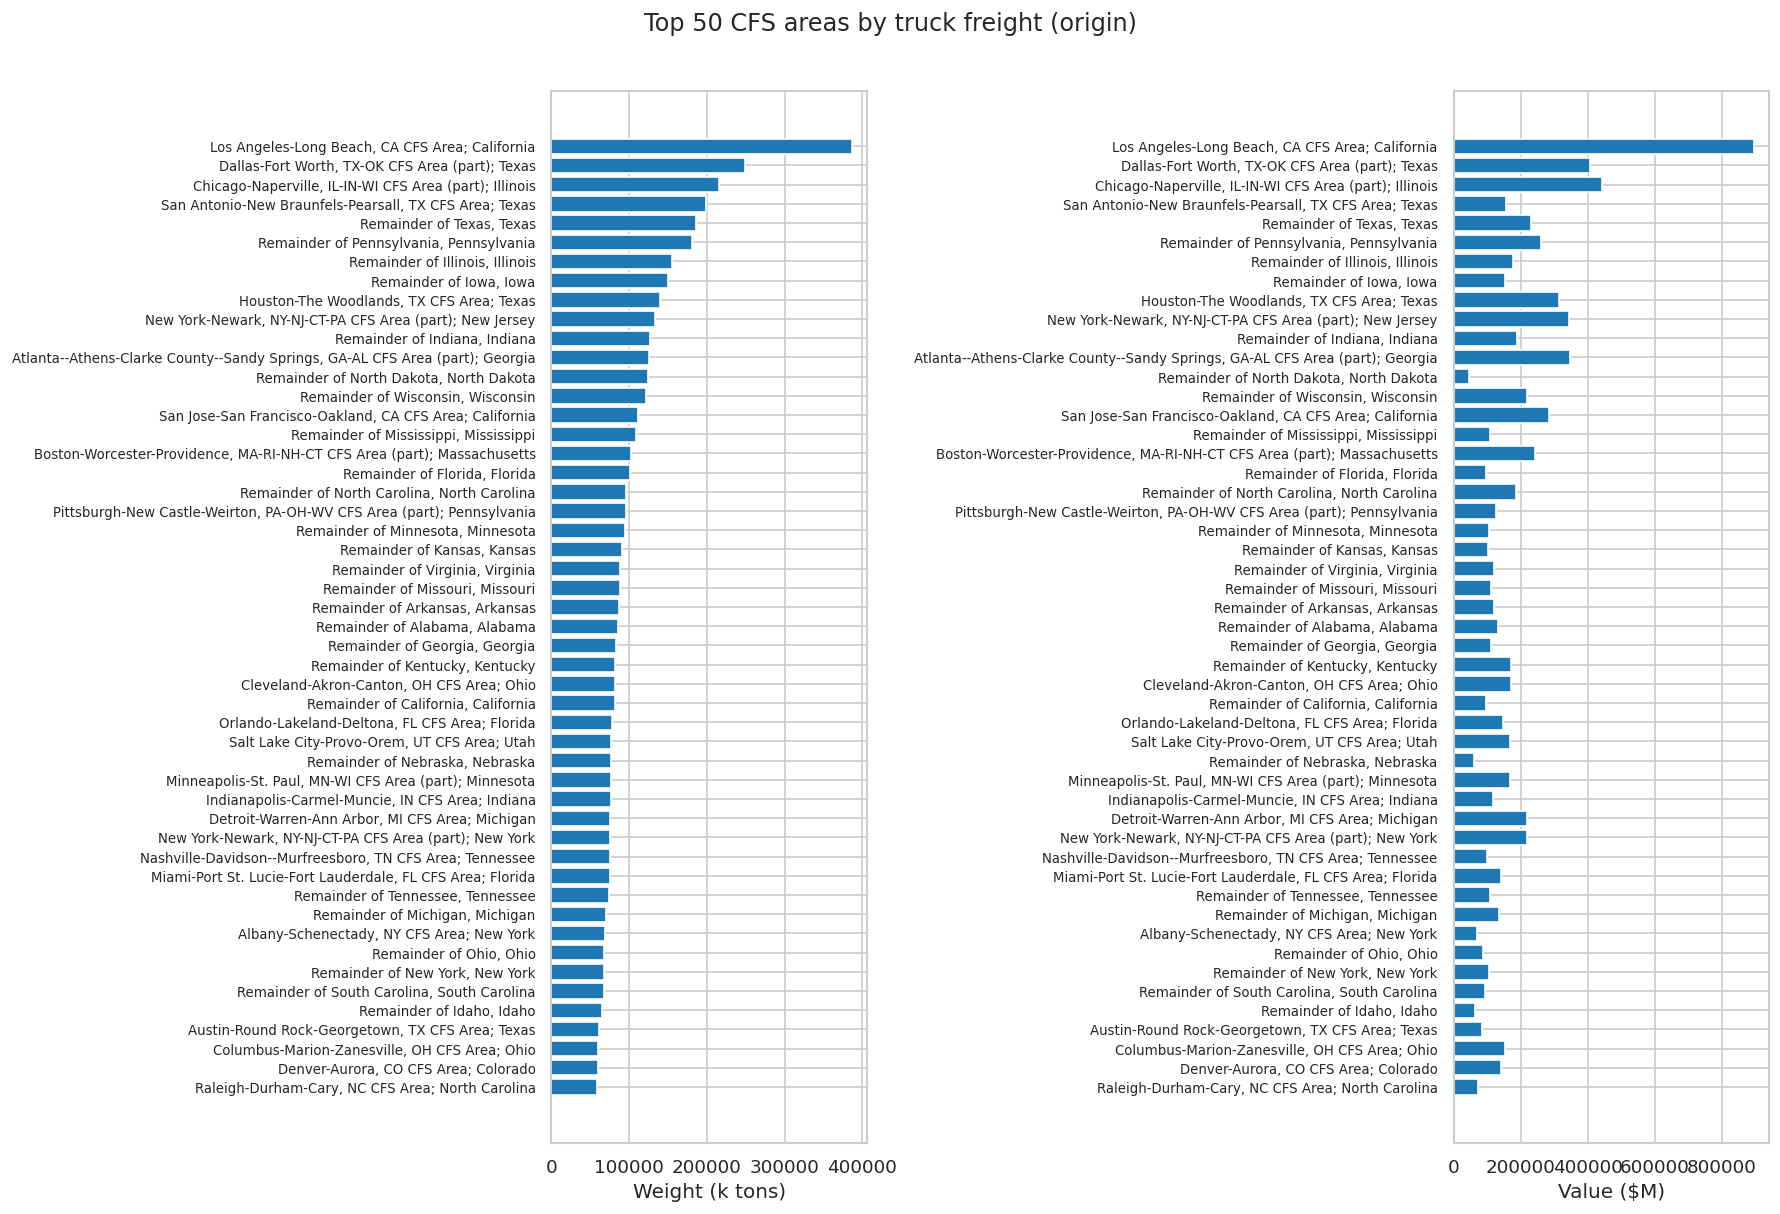

In [15]:
top_n = 50
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
for ax, col, unit in zip(axes, ['TON', 'VAL'], ['Weight (k tons)', 'Value ($M)']):
    data = cfs_truck.dropna(subset=[col]).head(top_n)
    ax.barh(data['GEO_LABEL'], data[col])
    ax.invert_yaxis()
    ax.set_xlabel(unit)
    ax.tick_params(axis='y', labelsize=8)
plt.suptitle(f'Top {top_n} CFS areas by truck freight (origin)', y=1.01)
plt.tight_layout()
plt.show()


# Analysis of long-distance shipments

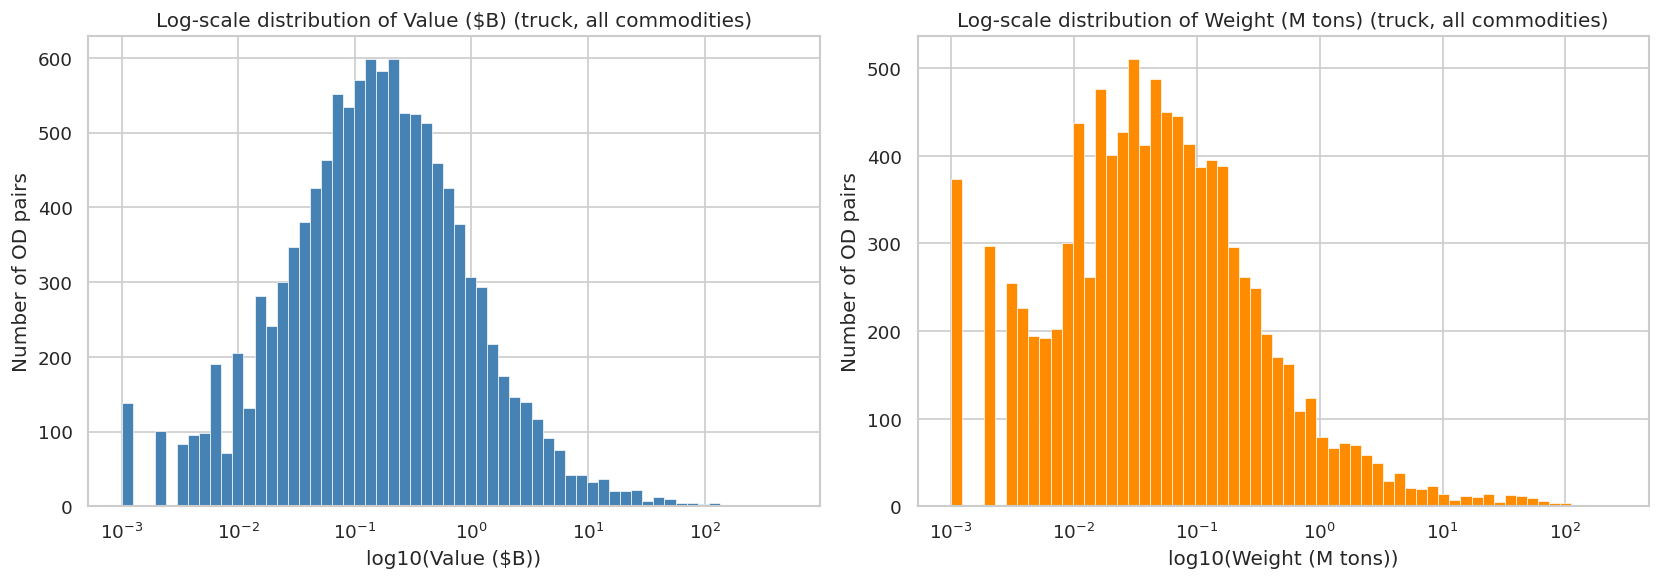

In [16]:
# Histograms of value and weight per CFS area shipment (DDESTGEO == '0100000US' totals excluded;
# use all OD rows so each row represents one origin-destination pair)
cfs_od = df[
    (df['GEOTYPE'] == '16') &
    (df['DMODE'] == '11') &
    (df['COMM'] == '0000') &
    (df['DDESTGEO'].str.startswith('E33'))  # exclude rolled-up totals
].copy()

# Log-scale version for heavy-tailed distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, unit, color in zip(
    axes,
    ['VAL', 'TON'],
    ['Value ($B)', 'Weight (M tons)'],
    ['steelblue', 'darkorange']
):
    data = cfs_od[col].dropna()
    data = data[data > 0]
    if col == 'VAL':
        data = data / 1000
    if col == 'TON':
        data = data / 1000
    ax.hist(np.log10(data), bins=60, color=color, edgecolor='white', linewidth=0.4)
    ax.set_xlabel(f'log10({unit})')
    ax.set_ylabel('Number of OD pairs')
    ax.set_title(f'Log-scale distribution of {unit} (truck, all commodities)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'$10^{{{x:.0f}}}$'))

plt.tight_layout()
plt.show()


In [17]:
od_truck = df[
    (df['GEOTYPE'] == '16') &
    (df['DDESTGEO'].str.startswith('E33')) &  # region destinations
    (df['DMODE'] == '11') &
    (df['COMM'] == '0000') & 
    (df['AVGMILE'] >= 300)
].dropna(subset=['TON']).copy()

od_truck['origin'] = od_truck['GEO_LABEL'].str.replace(r'^\d+\s+', '', regex=True)
od_truck['dest']   = od_truck['DDESTGEO_LABEL'].str.replace(r'^\d+\s+', '', regex=True)

print(f'OD pairs: {len(od_truck):,}')


OD pairs: 14,636


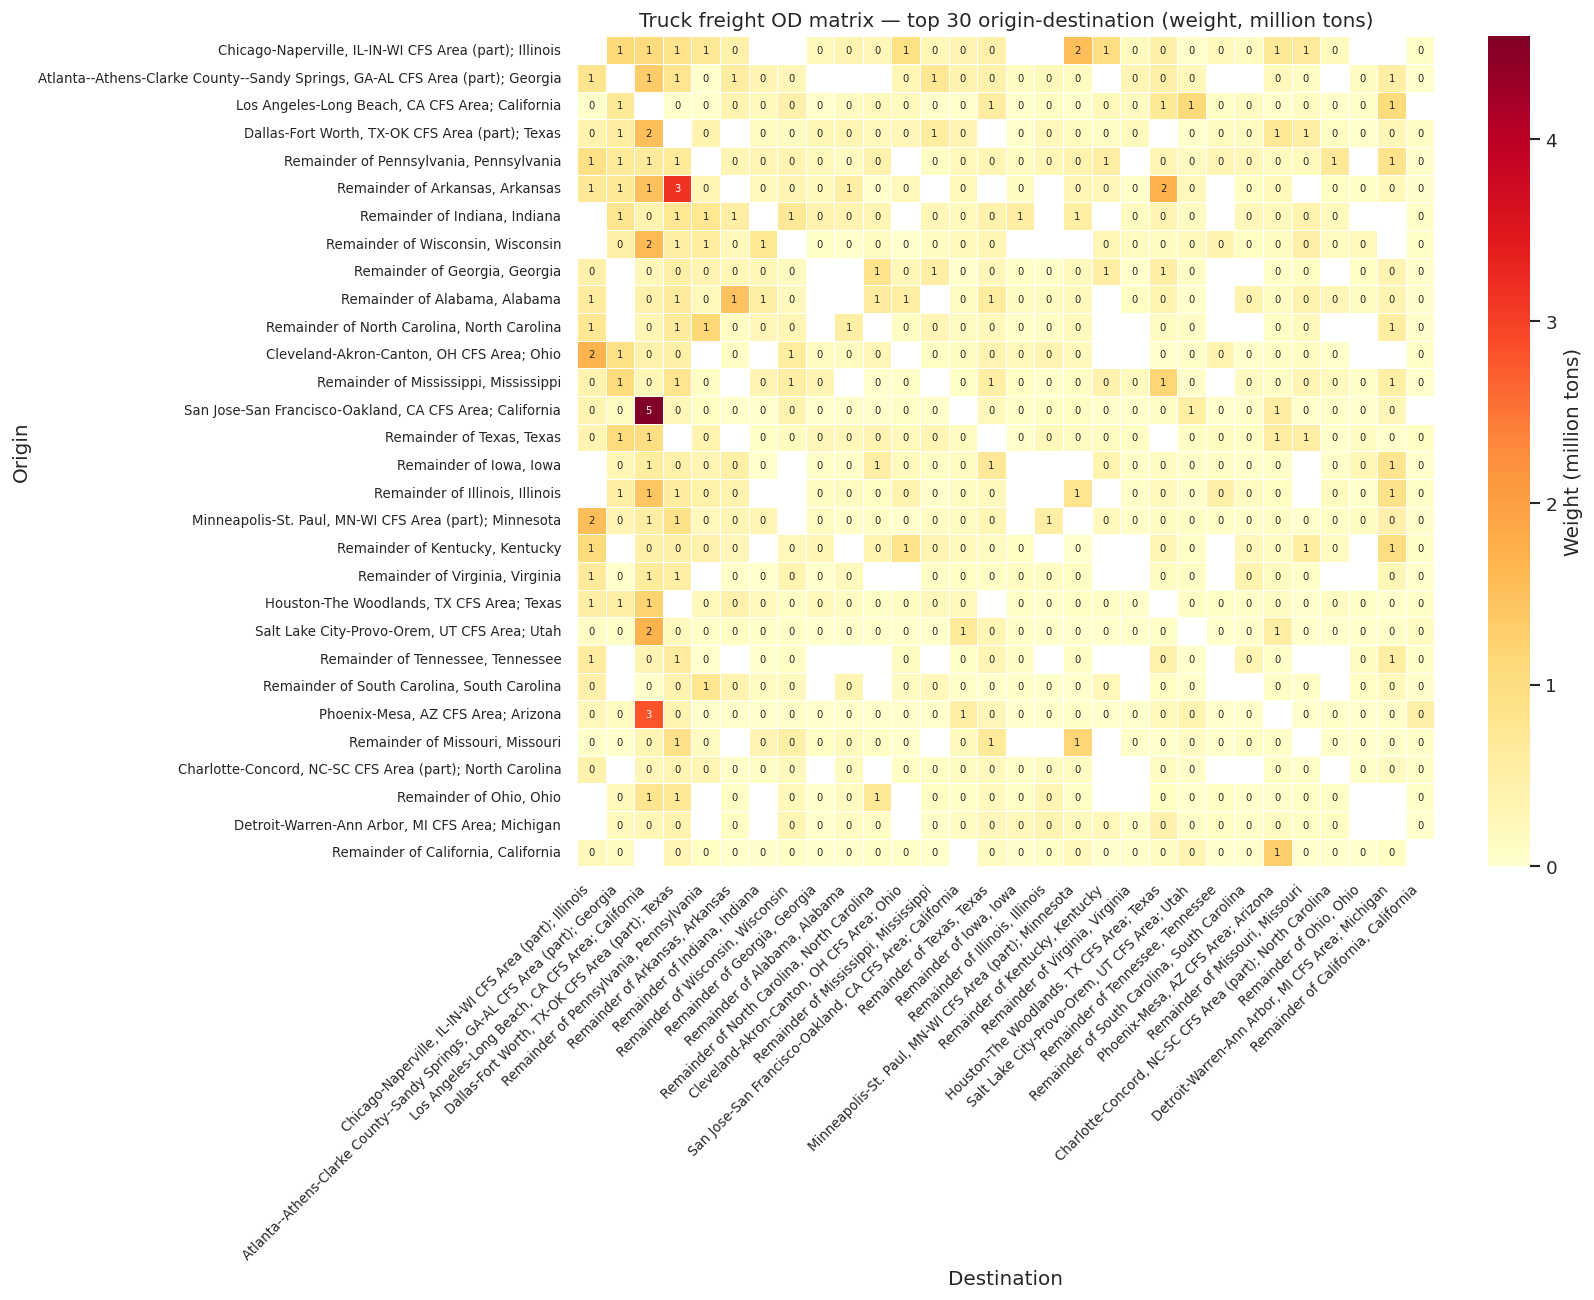

In [18]:
# Pivot to matrix; use top 20 states by total outbound volume
od_pivot = od_truck.pivot_table(index='origin', columns='dest', values='TON', aggfunc='sum')

top_states = od_truck.groupby('origin')['TON'].sum().nlargest(30).index
od_sub = od_pivot.loc[top_states, top_states]

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    od_sub / 1e3, ax=ax, cmap='YlOrRd', linewidths=0.3,
    fmt='.0f', annot=True, annot_kws={'size': 6},
    cbar_kws={'label': 'Weight (million tons)'}
)
ax.set_title('Truck freight OD matrix — top 30 origin-destination (weight, million tons)')
ax.set_xlabel('Destination')
ax.set_ylabel('Origin')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [27]:
sf_label = 'San Jose-San Francisco-Oakland, CA CFS Area; California'
la_label = 'Los Angeles-Long Beach, CA CFS Area; California'
phx_label = 'Phoenix-Mesa, AZ CFS Area; Arizona'
od_pivot[la_label][phx_label]

2816.0

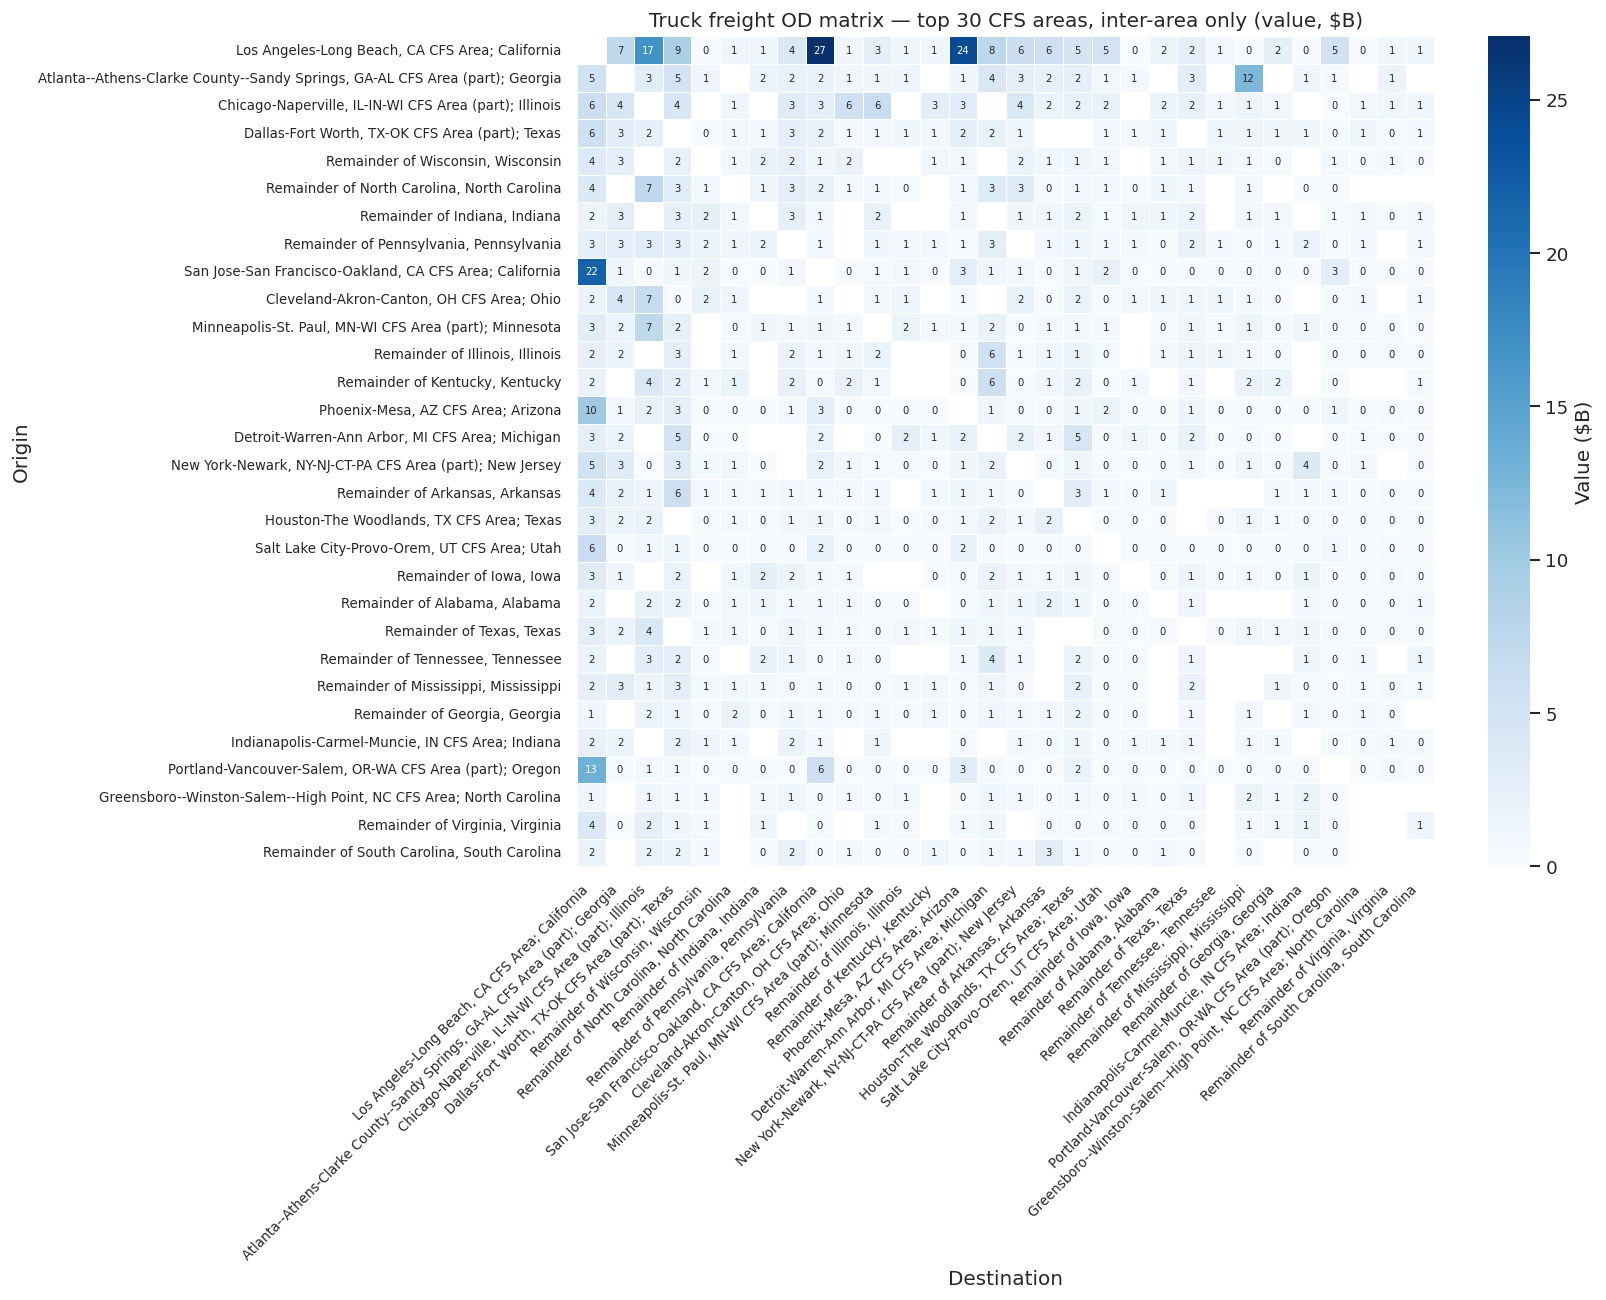

In [9]:
od_pivot_val = od_truck.pivot_table(index='origin', columns='dest', values='VAL', aggfunc='sum')

# Zero out diagonal
for label in od_pivot_val.index.intersection(od_pivot_val.columns):
    od_pivot_val.loc[label, label] = np.nan

top_areas_val = od_truck[od_truck['origin'] != od_truck['dest']].groupby('origin')['VAL'].sum().nlargest(30).index
od_sub_val = od_pivot_val.loc[top_areas_val, top_areas_val]

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    od_sub_val / 1e3, ax=ax, cmap='Blues', linewidths=0.3,
    fmt='.0f', annot=True, annot_kws={'size': 6},
    cbar_kws={'label': 'Value ($B)'}
)
ax.set_title('Truck freight OD matrix — top 30 CFS areas, inter-area only (value, $B)')
ax.set_xlabel('Destination')
ax.set_ylabel('Origin')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


If we want to consider the most heavily-used corridors (i.e. those with most weight), the top 3 are: 
* San Jose / San Francisco - Los Angeles / Long beach
* Phoenix/Meza - Los Angeles
* Remainder of Arkansas - Dallas

If we think of value of shipment as the measure of importance of a corridor, the top 3 are:
* LA - San Francisco 
* LA - Phoenix/Meza
* SF - LA 

The following network may be interesting: {LA, Phoenix, SF}; consider shipments from LA to SF, LA to Phoenix, and SF to LA. 

Ideally, a time horizon of 24 hours would be nice (one full day) - but initially, will try a time horizon of 6 hours. (Discretization of 15 minutes)

# Network properties
Assuming we do not allow proxy stations within 30 miles of each other

**LA - SF**: 9 charging stations, 28 proxy station sites. Drive time: ~6 hours (382 miles)

**LA - Phoenix**: 7 charging stations, 15 proxy station sites. Drive time: ~6 hours (373 miles)

**LA, SF, Phoenix**: 14 charging stations, 38 proxy station sites. 

## Long-haul vs. short-haul truck freight

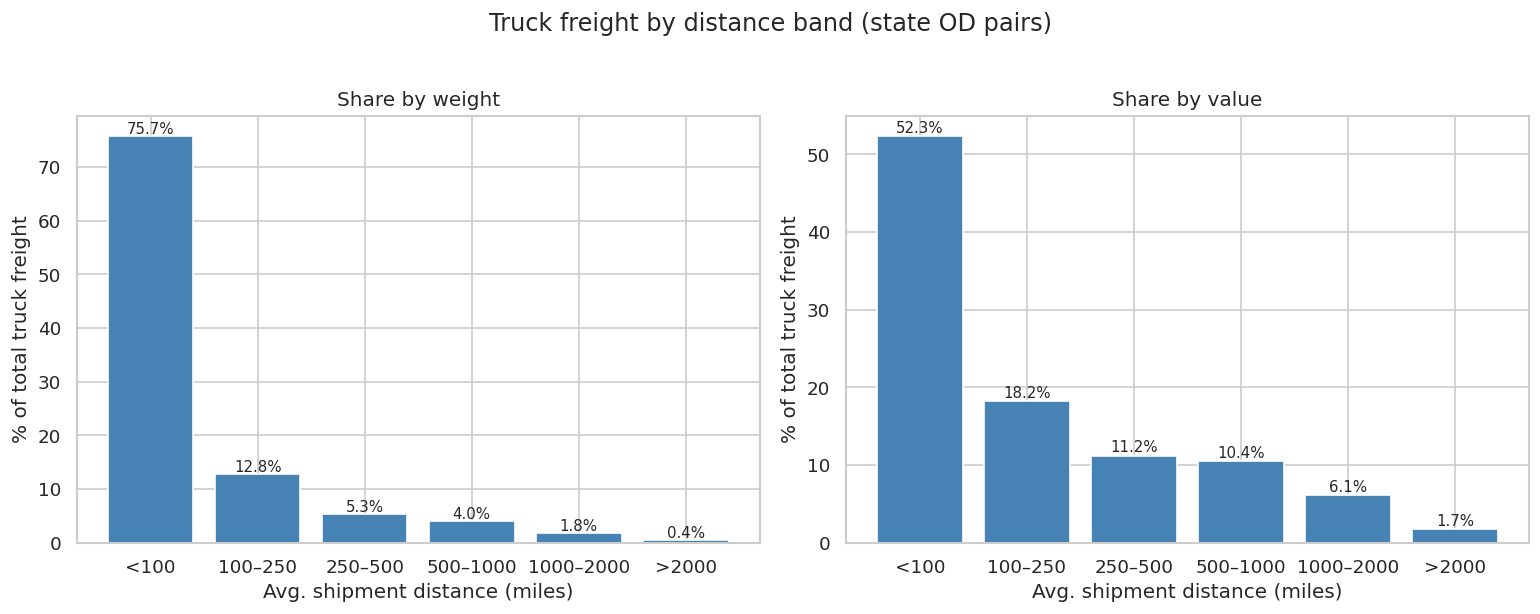


Long-haul (>250 mi) share:
  Weight: 11.5%
  Value:  29.4%


In [10]:
# State-level truck rows with explicit OD and AVGMILE
truck_od = df[
    (df['GEOTYPE'] == '16') &
    (df['DMODE'] == '11') &
    (df['COMM'] == '0000') &
    (df['DDESTGEO'].str.startswith('E33'))
].dropna(subset=['TON', 'AVGMILE']).copy()

bins   = [0, 100, 250, 500, 1000, 2000, np.inf]
labels = ['<100', '100–250', '250–500', '500–1000', '1000–2000', '>2000']
truck_od['dist_band'] = pd.cut(truck_od['AVGMILE'], bins=bins, labels=labels)

band_stats = truck_od.groupby('dist_band', observed=True)[['TON', 'VAL']].sum()
band_stats['TON_pct'] = band_stats['TON'] / band_stats['TON'].sum() * 100
band_stats['VAL_pct'] = band_stats['VAL'] / band_stats['VAL'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title in zip(axes, ['TON_pct', 'VAL_pct'], ['Share by weight', 'Share by value']):
    ax.bar(band_stats.index.astype(str), band_stats[col], color='steelblue', edgecolor='white')
    ax.set_xlabel('Avg. shipment distance (miles)')
    ax.set_ylabel('% of total truck freight')
    ax.set_title(title)
    for i, v in enumerate(band_stats[col]):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.suptitle('Truck freight by distance band (state OD pairs)', y=1.02)
plt.tight_layout()
plt.show()

print('\nLong-haul (>250 mi) share:')
lh = band_stats.loc[band_stats.index.isin(['250–500', '500–1000', '1000–2000', '>2000'])]
print(f'  Weight: {lh["TON_pct"].sum():.1f}%')
print(f'  Value:  {lh["VAL_pct"].sum():.1f}%')